If I take a few of this large returns, what are the features of it?

Were these returns explained partly by past volatility?
Was it explained by the sector, market or industry?
Has it anything to do with headlines?

In [1]:
import pandas as pd
import numpy as np

In [2]:
extreme_returns = pd.read_csv("data/sp500_sigma_extremes.csv")

extreme_returns

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%,log_return,index,Dividends,Stock Splits,z_score_global
0,2020-03-09,APA,13.420000,13.700000,9.320000,9.550000,8.224354,28073200.0,17.826614,-0.538647,-53.864746,-0.773593,NaN,NaN,NaN,-39.923853
1,2024-04-11,GL,98.480003,98.580002,38.950001,49.169998,48.298512,36577500.0,103.070229,-0.531402,-53.140192,-0.758010,NaN,NaN,NaN,-39.120169
2,2019-01-14,PCG,9.210000,9.730000,7.780000,8.380000,8.260254,127198800.0,17.338648,-0.523593,-52.359296,-0.741483,NaN,NaN,NaN,-38.267788
3,2020-03-09,OXY,15.580000,19.190001,12.040000,12.510000,11.708246,104930300.0,24.399191,-0.520138,-52.013793,-0.734257,35302.0,0.79,0.0,-37.895106
4,2025-10-29,FISV,71.360001,76.650002,66.580002,70.599998,70.599998,103454200.0,126.169998,-0.440438,-44.043751,-0.580600,NaN,NaN,NaN,-29.970347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11702,2015-07-16,SHW,85.356667,88.896667,83.423332,87.076668,78.755295,21494100.0,85.065247,-0.074178,-7.417779,-0.077073,NaN,NaN,NaN,-4.001186
11703,2010-07-30,FSLR,129.050003,130.000000,124.330002,125.449997,125.449997,5173800.0,135.500000,-0.074170,-7.416976,-0.077064,NaN,NaN,NaN,-4.000739
11704,2020-06-26,WFC,26.100000,26.400000,25.250000,25.340000,22.279022,81172300.0,24.063814,-0.074169,-7.416912,-0.077064,NaN,NaN,NaN,-4.000704
11705,2020-05-12,IVZ,7.840000,7.900000,7.240000,7.240000,5.691940,9350600.0,6.147924,-0.074169,-7.416872,-0.077063,NaN,NaN,NaN,-4.000681


In [3]:
# is there unique stock contributing?

extreme_returns["Ticker"].nunique()

423

The SP500 is constituted of about ~500 stocks (like the name suggests but some stocks are dropping and some are introduced.).
There are 423 tickers in the large extremes, meaning that most stocks have wide swings. But it also means that about 70 stocks behave differently and do not have these wild volatility events.

# Time Clustering

In [7]:
# is a specific period dominating?

extreme_returns["year"] = pd.to_datetime(extreme_returns["Date"]).dt.year

extreme_by_year = (
    extreme_returns
    .groupby("year")
    .size()
    .rename("n_events")
)

extreme_by_year

year
2010     427
2011    1033
2012     396
2013     242
2014     239
2015     354
2016     503
2017     228
2018     410
2019     361
2020    3931
2021     358
2022     812
2023     428
2024     578
2025    1097
2026     310
Name: n_events, dtype: int64

So a lot during bubble and crash years but also a lot during normal years. Keep in mind that this is 4 sigmas.

In [11]:
events_per_day = (
    extreme_returns
    .groupby("Date")
    .size()
    .sort_values(ascending=False)
)

events_per_day.head(10)

Date
2020-03-16    347
2020-03-12    320
2020-03-24    282
2020-03-09    210
2020-03-13    209
2011-08-08    192
2025-04-09    189
2020-04-06    187
2020-03-18    185
2020-03-17    159
dtype: int64

The covid years have seen incredible volatility

# sectors and industries

In [13]:
# join the returns and ticker list dataset to have access to sectors and industries

sp500_list = pd.read_csv("data/sp500_list.csv")

extreme_sector_n_industries = pd.merge(
    extreme_returns,
    sp500_list,
    left_on="Ticker",
    right_on= "ticker",
    how="inner"
)

extreme_sector_n_industries.head()

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,...,index_x,Dividends,Stock Splits,z_score_global,year,ticker,company_name,sector,industry,index_y
0,2020-03-09,APA,13.420000,13.700000,9.320000,9.550000,8.224354,28073200.0,17.826614,-0.538647,...,NaN,NaN,NaN,-39.923853,2020,APA,APA Corporation,Energy,Oil & Gas Exploration & Production,S&P500
1,2024-04-11,GL,98.480003,98.580002,38.950001,49.169998,48.298512,36577500.0,103.070229,-0.531402,...,NaN,NaN,NaN,-39.120169,2024,GL,Globe Life,Financials,Life & Health Insurance,S&P500
2,2019-01-14,PCG,9.210000,9.730000,7.780000,8.380000,8.260254,127198800.0,17.338648,-0.523593,...,NaN,NaN,NaN,-38.267788,2019,PCG,PG&E Corporation,Utilities,Multi-Utilities,S&P500
3,2020-03-09,OXY,15.580000,19.190001,12.040000,12.510000,11.708246,104930300.0,24.399191,-0.520138,...,35302.0,0.79,0.0,-37.895106,2020,OXY,Occidental Petroleum,Energy,Oil & Gas Exploration & Production,S&P500
4,2025-10-29,FISV,71.360001,76.650002,66.580002,70.599998,70.599998,103454200.0,126.169998,-0.440438,...,NaN,NaN,NaN,-29.970347,2025,FISV,Fiserv,Financials,Transaction & Payment Processing Services,S&P500


# Raw count by sectors
First, non normalized

In [14]:
events_by_sector = (
    extreme_sector_n_industries
    .groupby("sector")
    .size()
    .sort_values(ascending=False)
)

events_by_sector

sector
Information Technology    2513
Industrials               1618
Consumer Discretionary    1554
Financials                1344
Health Care               1199
Energy                     783
Materials                  749
Communication Services     599
Real Estate                501
Consumer Staples           488
Utilities                  359
dtype: int64

In [15]:
# here we need to be sure that the "buckets" of industries and sectors are about the same size so we normalize
# the problem did not appear for time clustering because each stock is quoted every day (few halting exceptions I decided to not consider)

# count per sector
stocks_per_sector = (
    sp500_list
    .groupby("sector")["ticker"]
    .nunique()
)

events_per_sector = extreme_sector_n_industries.groupby("sector").size()

intensity = (events_per_sector / stocks_per_sector).sort_values(ascending=False)

intensity

sector
Energy                    35.590909
Information Technology    34.424658
Consumer Discretionary    32.375000
Materials                 28.807692
Communication Services    26.043478
Health Care               20.672414
Industrials               20.481013
Financials                17.684211
Real Estate               16.161290
Consumer Staples          13.555556
Utilities                 11.580645
Index                           NaN
dtype: float64

Energy which was in the middle of the pack suddenly becomes quite volatile.

# Count by Industries

In [26]:
events_per_industries = (
    extreme_sector_n_industries
    .groupby("industry")
    .size()
    .sort_values(ascending=False)
)

events_per_industries

industry
Semiconductors                                874
Oil & Gas Exploration & Production            488
Technology Hardware, Storage & Peripherals    405
Health Care Equipment                         382
Application Software                          350
                                             ... 
Reinsurance                                     9
Data Processing & Outsourced Services           8
Gas Utilities                                   7
Multi-Sector Holdings                           7
Water Utilities                                 6
Length: 118, dtype: int64

In [ ]:
# normalized
# I need to inner join both because some industries have little stocks and hence none crossed the 4 sigma

stocks_per_industries = (
    sp500_list
    .groupby("industry")["ticker"]
    .nunique()
)

events_per_industries, stocks_per_industries = events_per_industries.align(
    stocks_per_industries,
    join="inner"
)

intensity = (events_per_industries / stocks_per_industries).sort_values(ascending=False)



In [29]:
intensity

industry
Copper                                   111.000000
Casinos & Gaming                          75.333333
Footwear                                  66.000000
Passenger Airlines                        65.666667
Semiconductors                            62.428571
                                            ...    
Environmental & Facilities Services        6.250000
Water Utilities                            6.000000
Integrated Telecommunication Services      6.000000
Household Products                         5.250000
Cable & Satellite                          4.500000
Length: 118, dtype: float64

# Pragmatic questions for investors

In [35]:
# -----------------------------
# 2. Define direction of returns
# -----------------------------
# Positive = 1, Negative = -1
extreme_returns["direction"] = np.where(
    extreme_returns["arithmetic_return"] > 0,
    "positive",
    "negative"
)

# -----------------------------
# 3. Count extreme events per year and direction
# -----------------------------
yearly_sign = (
    extreme_returns
    .groupby(["year", "direction"])
    .size()
    .unstack(fill_value=0)
)

# -----------------------------
# 4. Add useful metrics
# -----------------------------

# Net imbalance: positive - negative extremes
yearly_sign["net"] = yearly_sign["positive"] - yearly_sign["negative"]

# Ratio of positive extremes (avoid division issues)
yearly_sign["ratio_positive"] = (
    yearly_sign["positive"] /
    (yearly_sign["positive"] + yearly_sign["negative"])
)

# -----------------------------
# 5. Optional: magnitude-based view
# -----------------------------

# Mean extreme return per year (signed)
yearly_mean_return = (
    extreme_returns
    .groupby("year")["arithmetic_return"]
    .mean()
)

# Median extreme return per year (robust to outliers)
yearly_median_return = (
    extreme_returns
    .groupby("year")["arithmetic_return"]
    .median()
)

# -----------------------------
# 6. Combine everything into one table (optional)
# -----------------------------
yearly_analysis = yearly_sign.copy()
yearly_analysis["mean_return"] = yearly_mean_return
yearly_analysis["median_return"] = yearly_median_return

# -----------------------------
# 7. Output
# -----------------------------
print(yearly_analysis.sort_index())

direction  negative  positive  net  ratio_positive  mean_return  median_return
year                                                                          
2010            187       240   53        0.562061     0.018075       0.083744
2011            620       413 -207        0.399806    -0.014744      -0.077181
2012            197       199    2        0.502525     0.004654       0.081343
2013            109       133   24        0.549587     0.023288       0.084996
2014            112       127   15        0.531381     0.012916       0.082025
2015            181       173   -8        0.488701     0.003884      -0.074584
2016            299       204  -95        0.405567    -0.012949      -0.077708
2017            117       111   -6        0.486842     0.003145      -0.074968
2018            245       165  -80        0.402439    -0.014277      -0.078072
2019            180       181    1        0.501385     0.003868       0.081218
2020           2050      1881 -169        0.478504  

In [33]:
# mean direction
sector_mean = (
    extreme_sector_n_industries
    .groupby("sector")["arithmetic_return"]
    .mean()
)

# median (robust)
sector_median = (
    extreme_sector_n_industries
    .groupby("sector")["arithmetic_return"]
    .median()
)

# % positive
sector_pos_ratio = (
    extreme_sector_n_industries
    .groupby("sector")["arithmetic_return"]
    .apply(lambda x: (x > 0).mean())
)

print("Mean and median extreme returns show more negative. With a slight right skew.\n")
print(sector_mean,"\n")
print(sector_median,"\n")
print("The probabilites of having a positive extreme return are less than a negative one. But not by much.\n")
print(sector_pos_ratio)

Mean and median extreme returns show more negative. With a slight right skew.

sector
Communication Services    0.008812
Consumer Discretionary    0.002873
Consumer Staples         -0.012327
Energy                   -0.003026
Financials               -0.011308
Health Care              -0.000964
Industrials              -0.002528
Information Technology    0.000793
Materials                -0.010181
Real Estate               0.002247
Utilities                -0.014687
Name: arithmetic_return, dtype: float64 

sector
Communication Services    0.081290
Consumer Discretionary   -0.074289
Consumer Staples         -0.077474
Energy                   -0.075863
Financials               -0.077371
Health Care              -0.075241
Industrials              -0.076040
Information Technology   -0.075591
Materials                -0.076959
Real Estate               0.081269
Utilities                -0.079436
Name: arithmetic_return, dtype: float64 

The probabilites of having a positive extreme return 

# Visualization

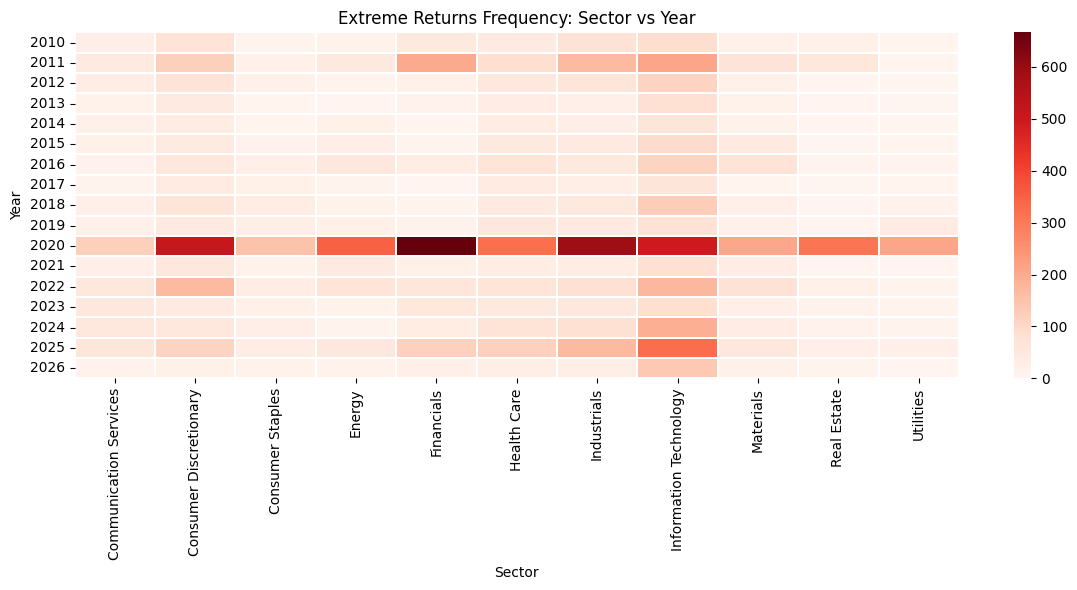

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Year x Sector counts
# -----------------------------
year_sector = (
    extreme_sector_n_industries
    .groupby(["year", "sector"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12, 6))
sns.heatmap(year_sector, cmap="Reds", linewidths=0.2)

plt.title("Extreme Returns Frequency: Sector vs Year")
plt.xlabel("Sector")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

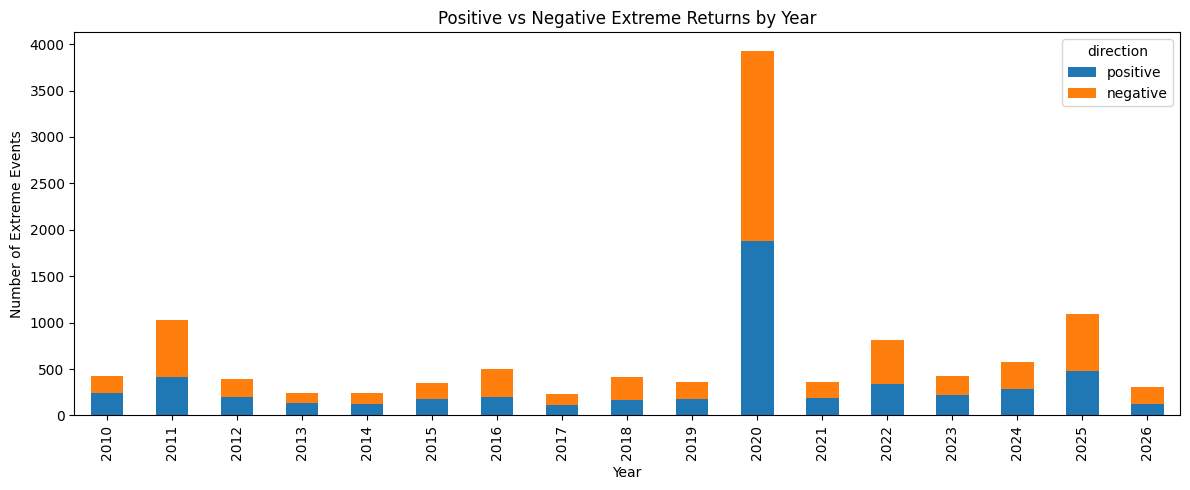

In [37]:
yearly_sign[["positive", "negative"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5)
)

plt.title("Positive vs Negative Extreme Returns by Year")
plt.xlabel("Year")
plt.ylabel("Number of Extreme Events")
plt.tight_layout()
plt.show()

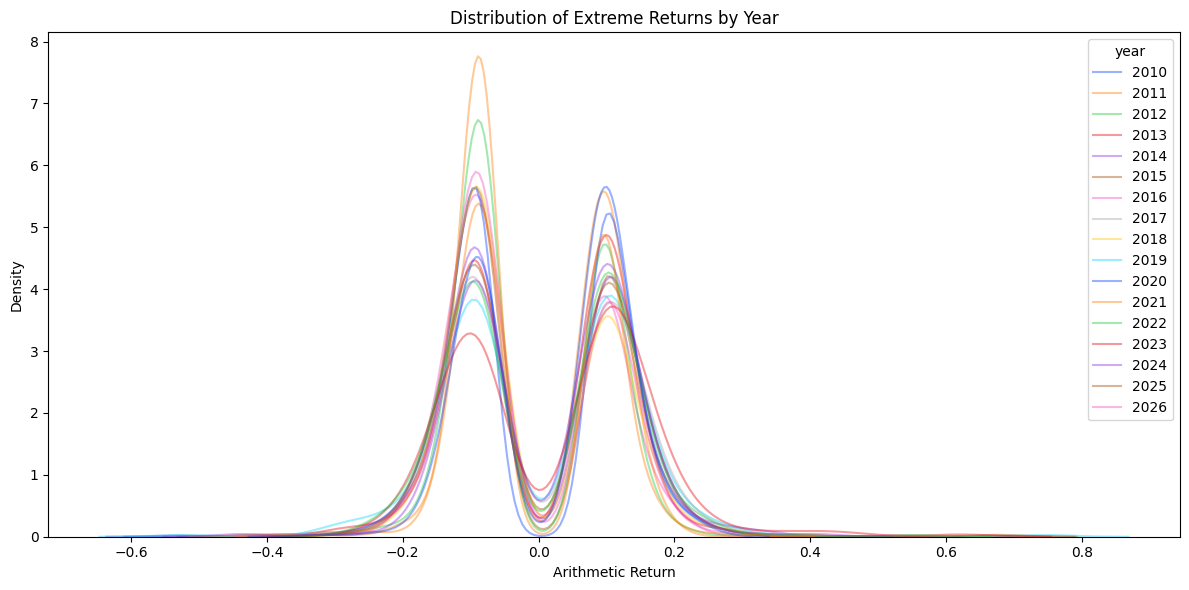

In [40]:
plt.figure(figsize=(12, 6))

sns.kdeplot(
    data=extreme_returns,
    x="arithmetic_return",
    hue="year",
    common_norm=False,
    alpha=0.4,
    palette="bright"
)

plt.title("Distribution of Extreme Returns by Year")
plt.xlabel("Arithmetic Return")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [42]:
extreme_returns

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%,log_return,index,Dividends,Stock Splits,z_score_global,year,direction
0,2020-03-09,APA,13.420000,13.700000,9.320000,9.550000,8.224354,28073200.0,17.826614,-0.538647,-53.864746,-0.773593,NaN,NaN,NaN,-39.923853,2020,negative
1,2024-04-11,GL,98.480003,98.580002,38.950001,49.169998,48.298512,36577500.0,103.070229,-0.531402,-53.140192,-0.758010,NaN,NaN,NaN,-39.120169,2024,negative
2,2019-01-14,PCG,9.210000,9.730000,7.780000,8.380000,8.260254,127198800.0,17.338648,-0.523593,-52.359296,-0.741483,NaN,NaN,NaN,-38.267788,2019,negative
3,2020-03-09,OXY,15.580000,19.190001,12.040000,12.510000,11.708246,104930300.0,24.399191,-0.520138,-52.013793,-0.734257,35302.0,0.79,0.0,-37.895106,2020,negative
4,2025-10-29,FISV,71.360001,76.650002,66.580002,70.599998,70.599998,103454200.0,126.169998,-0.440438,-44.043751,-0.580600,NaN,NaN,NaN,-29.970347,2025,negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11702,2015-07-16,SHW,85.356667,88.896667,83.423332,87.076668,78.755295,21494100.0,85.065247,-0.074178,-7.417779,-0.077073,NaN,NaN,NaN,-4.001186,2015,negative
11703,2010-07-30,FSLR,129.050003,130.000000,124.330002,125.449997,125.449997,5173800.0,135.500000,-0.074170,-7.416976,-0.077064,NaN,NaN,NaN,-4.000739,2010,negative
11704,2020-06-26,WFC,26.100000,26.400000,25.250000,25.340000,22.279022,81172300.0,24.063814,-0.074169,-7.416912,-0.077064,NaN,NaN,NaN,-4.000704,2020,negative
11705,2020-05-12,IVZ,7.840000,7.900000,7.240000,7.240000,5.691940,9350600.0,6.147924,-0.074169,-7.416872,-0.077063,NaN,NaN,NaN,-4.000681,2020,negative
